MAP-MRP  | RMSE nhỏ nhất: vòng 401 | RMSE = 7.21565 | Thời gian = 76.494 s
OSEM-MRP | RMSE nhỏ nhất: vòng 88 | RMSE = 7.44278 | Thời gian = 17.092 s
Hiệu suất giảm thời gian = 77.66%


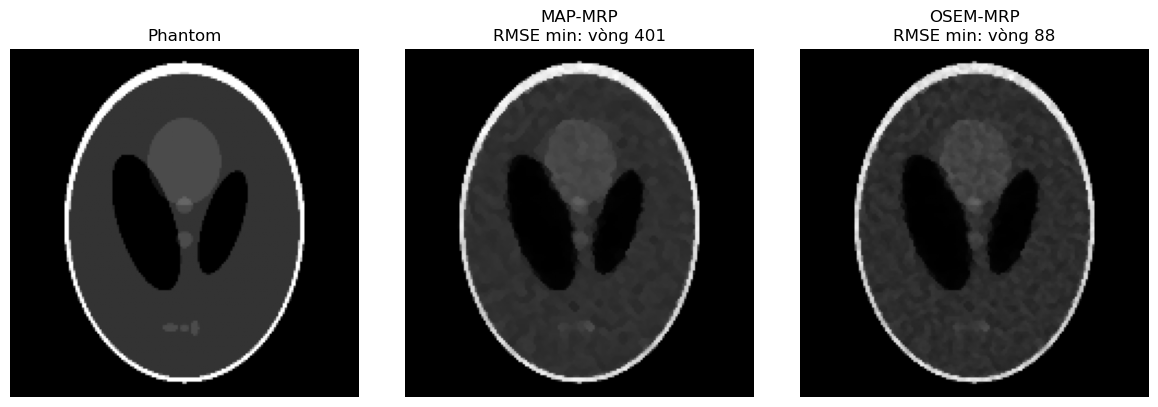

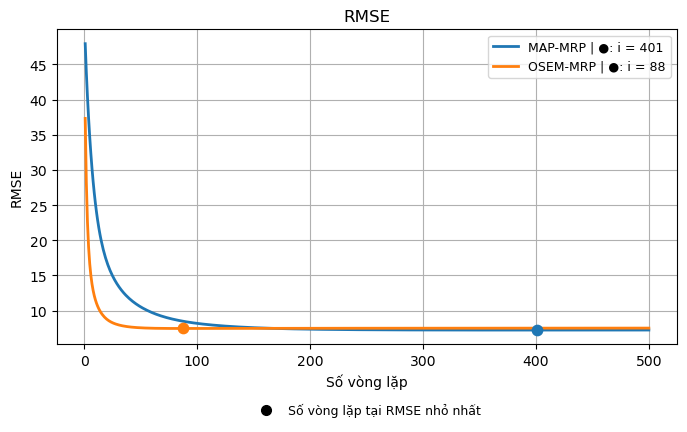

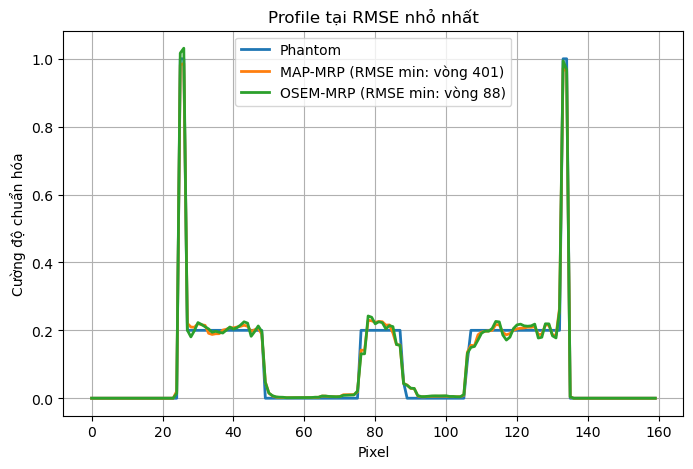

In [1]:
# ===================== MAP-MRP và OSEM-MRP =====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import median_filter
from skimage import io, data_dir
from skimage.transform import radon, iradon
import os, time
# ==================== Thông số =====================
niter = 500
counts = int(5e6)
n_subsets = 4
beta = 0.3
eps = 1e-6
# ==================== Phantom và dữ liệu chiếu =====================
image = io.imread(os.path.join(data_dir, "phantom160.png"), as_gray=True).astype(np.float32)
theta = np.arange(0, 180, 1)
sinogram = radon(image, theta, circle=False)
total = sinogram.sum()
measured = np.random.poisson(sinogram / total * counts).astype(np.float32)
measured *= total / counts
# ==================== MAP-MRP ====================
start = time.perf_counter()
sensitivity = np.maximum(
    iradon(np.ones_like(measured), theta,
           filter_name=None, circle=False), eps
)

x = np.ones_like(image)
mrp_rmse, mrp_time = [], []
mrp_best_rmse, mrp_best_iter, mrp_best_img = np.inf, 0, None

for k in range(niter):
    proj = radon(x, theta, circle=False)
    ratio = measured / (proj + eps)
    back = iradon(ratio, theta, filter_name=None, circle=False)
    update = np.maximum(x * back / sensitivity, eps)

    med = median_filter(x, size=3, mode="reflect")
    penalty = np.maximum(1 + beta * (x - med) / (med + eps), eps)
    x = np.maximum(update / penalty, eps)

    e = np.sqrt(np.mean((image - x) ** 2))
    mrp_rmse.append(e)
    mrp_time.append(time.perf_counter() - start)

    if e < mrp_best_rmse:
        mrp_best_rmse, mrp_best_iter, mrp_best_img = e, k + 1, x.copy()

mrp_best_time = mrp_time[mrp_best_iter - 1]

# ==================== OSEM-MRP ====================
start = time.perf_counter()
subsets = [np.arange(s, len(theta), n_subsets) for s in range(n_subsets)]
sensitivity_subs = []

for idx in subsets:
    theta_sub = theta[idx]
    measured_sub = measured[:, idx]
    sensitivity_subs.append(np.maximum(
        iradon(np.ones_like(measured_sub), theta_sub,
               filter_name=None, circle=False), eps
    ))

x = np.ones_like(image)
osem_rmse, osem_time = [], []
osem_best_rmse, osem_best_iter, osem_best_img = np.inf, 0, None

for k in range(niter):
    for j, idx in enumerate(subsets):
        theta_sub = theta[idx]
        measured_sub = measured[:, idx]
        proj = radon(x, theta_sub, circle=False)
        ratio = measured_sub / (proj + eps)
        back = iradon(ratio, theta_sub, filter_name=None, circle=False)
        x = np.maximum(x * back / sensitivity_subs[j], eps)

    med = median_filter(x, size=3, mode="reflect")
    penalty = np.maximum(1 + beta * (x - med) / (med + eps), eps)
    x = np.maximum(x / penalty, eps)
    e = np.sqrt(np.mean((image - x) ** 2))
    osem_rmse.append(e)
    osem_time.append(time.perf_counter() - start)

    if e < osem_best_rmse:
        osem_best_rmse, osem_best_iter, osem_best_img = e, k + 1, x.copy()
osem_best_time = osem_time[osem_best_iter - 1]

# ===================== Kết quả =====================

time_reduction = (mrp_best_time - osem_best_time) / mrp_best_time * 100

print(f'MAP-MRP  | RMSE nhỏ nhất: vòng {mrp_best_iter} | RMSE = {mrp_best_rmse:.5f} | Thời gian = {mrp_best_time:.3f} s')
print(f'OSEM-MRP | RMSE nhỏ nhất: vòng {osem_best_iter} | RMSE = {osem_best_rmse:.5f} | Thời gian = {osem_best_time:.3f} s')
print(f'Hiệu suất giảm thời gian = {time_reduction:.2f}%')

# ===================== Ảnh tái tạo =====================

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap="gray"); ax[0].set_title("Phantom")
ax[1].imshow(mrp_best_img, cmap="gray"); ax[1].set_title(f"MAP-MRP\nRMSE min: vòng {mrp_best_iter}")
ax[2].imshow(osem_best_img, cmap="gray"); ax[2].set_title(f"OSEM-MRP\nRMSE min: vòng {osem_best_iter}")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

# ===================== RMSE =====================

iteration = np.arange(1, niter + 1)
fig, ax = plt.subplots(figsize=(8, 5))

line_mrp, = ax.plot(iteration, mrp_rmse, lw=2)
color_mrp = line_mrp.get_color()
line_osem, = ax.plot(iteration, osem_rmse, lw=2)
color_osem = line_osem.get_color()

ax.scatter(mrp_best_iter, mrp_best_rmse, s=55, color=color_mrp, zorder=5)
ax.scatter(osem_best_iter, osem_best_rmse, s=55, color=color_osem, zorder=5)

label_mrp = f'MAP-MRP | ●: i = {mrp_best_iter}'
label_osem = f'OSEM-MRP | ●: i = {osem_best_iter}'
legend1 = ax.legend([line_mrp, line_osem], [label_mrp, label_osem],
                    loc="upper right", fontsize=9)
ax.add_artist(legend1)

ax.set_title("RMSE")
ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("RMSE")
ax.grid(True)

handle_min = Line2D([0], [0], marker="o", linestyle="None",
                    markerfacecolor="black", markeredgecolor="black",
                    markersize=7)
ax.legend([handle_min], ["Số vòng lặp tại RMSE nhỏ nhất"],
          loc="upper center", bbox_to_anchor=(0.5, -0.15),
          frameon=False, fontsize=9)

plt.subplots_adjust(bottom=0.25)
plt.show()

# ===================== Profile =====================

center = image.shape[0] // 2
phantom_min = image.min()
phantom_range = image.max() - image.min()

def get_profile(img):
    return (img[center, :] - phantom_min) / phantom_range

plt.figure(figsize=(8, 5))
plt.plot(get_profile(image), lw=2, label="Phantom")
plt.plot(get_profile(mrp_best_img), lw=2,
         label=f"MAP-MRP (RMSE min: vòng {mrp_best_iter})")
plt.plot(get_profile(osem_best_img), lw=2,
         label=f"OSEM-MRP (RMSE min: vòng {osem_best_iter})")
plt.title("Profile tại RMSE nhỏ nhất")
plt.xlabel("Pixel")
plt.ylabel("Cường độ chuẩn hóa")
plt.grid(True)
plt.legend()
plt.show()